# C5-ex2: Practice on k-Nearest Neighbors Regression (k-NN Regressor)

**Nguyễn Phúc Minh Châu - 22302421**

This exercise will help you understand how the **k-Nearest Neighbors (k-NN)** algorithm works for **regression** problems.

Answer each question in the code cell below it.

## Question 1
**Load the Diabetes dataset and display the first 5 rows of data.**

_Hint: Use `load_diabetes()` from `sklearn.datasets` and convert it into a DataFrame._

In [3]:
# Hiển thị 5 dòng đầu tiên của dữ liệu Diabetes
from sklearn.datasets import load_diabetes
import pandas as pd

# TODO: Tải dữ liệu
data = load_diabetes()

# TODO: Tạo DataFrame từ dữ liệu
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## Question 2
**Split the dataset into 70% training and 30% testing sets.**

_Hint: Use `train_test_split()` from `sklearn.model_selection`._

In [4]:
# Chia dữ liệu thành tập huấn luyện và kiểm tra
from sklearn.model_selection import train_test_split

# TODO: X và y
X = data.data
y = data.target

# TODO: Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.shape, X_test.shape)

(309, 10) (133, 10)


## Question 3
**Train a k-Nearest Neighbors Regressor with k = 5 and evaluate its performance using Mean Squared Error (MSE).**

In [5]:
# Huấn luyện mô hình KNN hồi quy và đánh giá MSE
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# TODO: Khởi tạo mô hình hồi quy với k=5
knn_reg = KNeighborsRegressor(n_neighbors=5)

# TODO: Huấn luyện mô hình
knn_reg.fit(X_train, y_train)

# TODO: Dự đoán trên tập kiểm tra
y_pred = knn_reg.predict(X_test)

# TODO: Tính MSE
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 3222.117894736842


## Question 4
**Compare performance for different values of k (e.g., 1, 3, 5, 9, 15). Which value gives the lowest MSE?**

In [7]:
# So sánh kết quả hồi quy khi thay đổi giá trị k
import numpy as np

ks = [1, 3, 5, 9, 15]
mse_scores = {}

for k in ks:
    # TODO: Huấn luyện và dự đoán cho từng giá trị k
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_scores[k] = mse
    print(f"k = {k}, MSE = {mse:.2f}")

# Find the best k
best_k = min(mse_scores, key=mse_scores.get)
print(f"\nBest k: {best_k} with MSE = {mse_scores[best_k]:.2f}")

k = 1, MSE = 5629.61
k = 3, MSE = 3663.82
k = 5, MSE = 3222.12
k = 9, MSE = 3175.55
k = 15, MSE = 3047.88

Best k: 15 with MSE = 3047.88


## Question 5
**Visualize the true vs predicted values for the best model (the one with the lowest MSE).**

_Hint: Use `matplotlib.pyplot.scatter()` to plot y_test and y_pred._

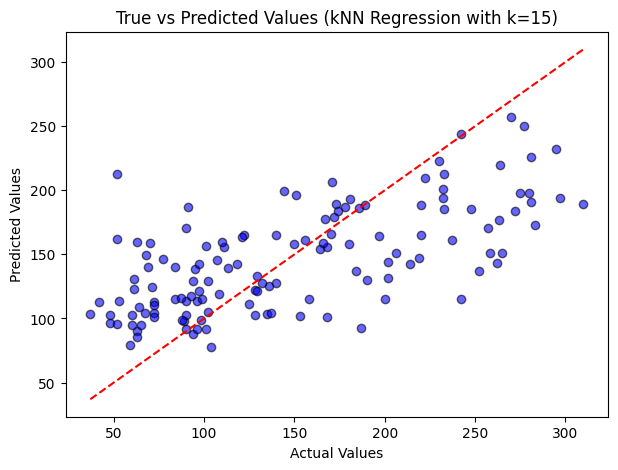

In [9]:
# Trực quan hóa giá trị thực tế và giá trị dự đoán
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor

# Assume model_best is the model with the smallest MSE
model_best = KNeighborsRegressor(n_neighbors=best_k)
model_best.fit(X_train, y_train)
y_pred_best = model_best.predict(X_test)

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_best, color='blue', edgecolor='k', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'True vs Predicted Values (kNN Regression with k={best_k})')
plt.show()

## Question 6
**Explain: What happens when k is too small or too large in k-NN regression?**

- When k is too small (e.g., k=1):
  + The model becomes very sensitive to noise in the training data. It essentially memorizes the training data points, leading to a highly complex decision boundary (or regression surface).
  + This results in high variance and can lead to overfitting, where the model performs well on the training data but poorly on unseen test data. The predictions will be jumpy and not smooth.
- When k is too large (e.g., k close to the number of data points):
  + The model becomes too smooth and loses the ability to capture local patterns in the data.
  + It averages the target values of a large number of neighbors, including those far away from the query point. This results in high bias and can lead to underfitting, where the model performs poorly on both the training and test data.
  + The predictions will be overly generalized and may not accurately reflect the underlying relationship in the data.

_Choosing an appropriate value of k is a trade-off between bias and variance. Cross-validation is often used to find the optimal k that minimizes the error on unseen data._

## Extra note:

**The main difference between k-Nearest Neighbors (k-NN) classification and k-NN regression** lies in the type of problem they are used for and how they make predictions:

- **k-NN Classification**: This is used for classification problems, where the goal is to predict a categorical output (i.e., which class a data point belongs to). The prediction is made by looking at the k nearest neighbors of the new data point and assigning it the class that is most frequent among those neighbors (majority vote).

- **k-NN Regression**: This is used for regression problems, where the goal is to predict a continuous numerical output. The prediction is made by looking at the k nearest neighbors of the new data point and calculating the average (or sometimes weighted average) of their target variable values.

_In summary:_

Classification: Predicts a category by majority vote among neighbors.
Regression: Predicts a number by averaging the values of neighbors.
Both methods rely on the principle of proximity – assuming that similar data points are close to each other in the feature space. The key distinction is how the final prediction is derived from the neighbors' information.